DEVICE: cuda
Rows after cleaning: 4022
Number of features used: 9
Features used: ['ma_gap_20', 'ma_gap_10', 'vol_10', 'ret_2', 'ret_5', 'ret_1', 'ret_4', 'vol_20', 'ret_3']

Target mapping:
  > 0.02 -> Uptrend (2)
  < -0.02 -> Downtrend (0)
  otherwise -> Sideway (1)
Class distribution: {'Downtrend': 1041, 'Sideway': 1417, 'Uptrend': 1564}

Windowed data shape: (4008, 14, 9)
Dev shape : (3607, 14, 9) (3607,)
Test shape: (401, 14, 9) (401,)

Walk-forward splits:
Fold 1: train=2164, val=360, train range=[0,2163], val range=[2164,2523]
Fold 2: train=2524, val=360, train range=[0,2523], val range=[2524,2883]
Fold 3: train=2884, val=360, train range=[0,2883], val range=[2884,3243]

Walk-forward GRU grid search: 16 combinations

[01/16] hs=32, layers=1, drop=0.2, lr=0.0005 -> mean_val_acc=0.3750, mean_val_f1=0.3647, mean_val_loss=1.0859, mean_val_auc=0.5525
[02/16] hs=32, layers=1, drop=0.2, lr=0.001 -> mean_val_acc=0.3602, mean_val_f1=0.3456, mean_val_loss=1.0956, mean_val_auc=0.5282
[03/16

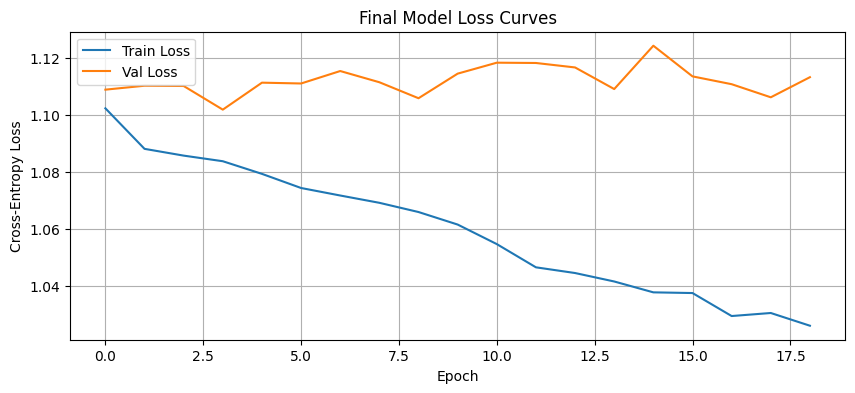

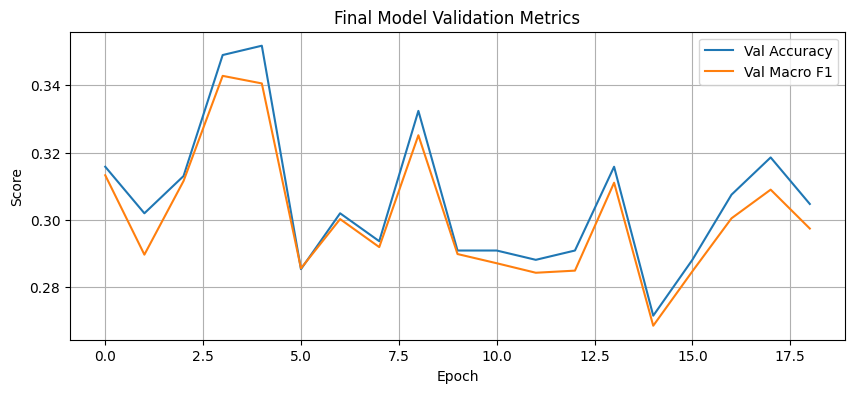

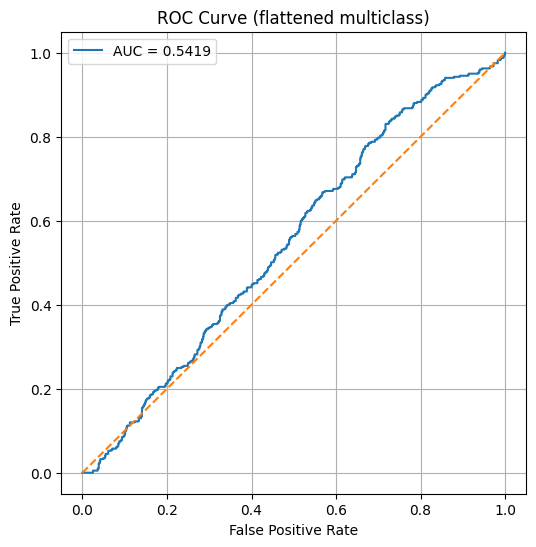

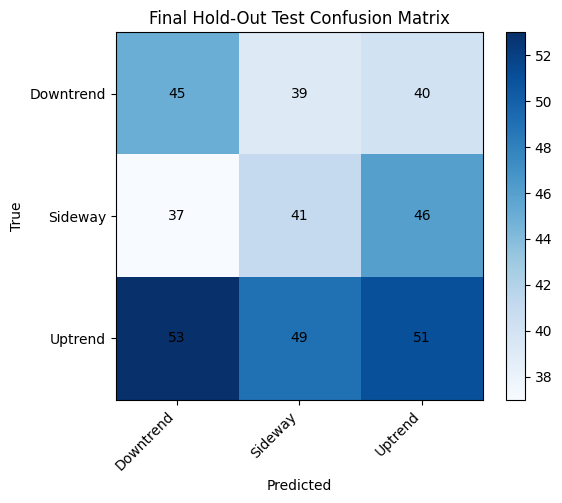


Saved files:
 - gru_walkforward_grid_results.csv
 - gru_walkforward_final_test_predictions.csv


In [7]:
# ============================================================
# GRU Classification with Walk-Forward Validation + Final Hold-Out Test
# - PyTorch
# - 3 classes from Target_Return_7d
# - Threshold = ±0.02
# - Evaluation style aligned with previous file:
#   log loss, confusion matrix, macro precision/recall/specificity/F1,
#   per-class metrics, MSE/RMSE/R2 on label-encoded classes, OvR macro AUC,
#   ROC curve, loss curves
# ============================================================

import os
import copy
import math
import random
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    log_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

# ============================================================
# 1) CONFIG
# ============================================================
WINDOW_SIZE = 14
CSV_PATH = "../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv"
TARGET_COL = "Target_Return_7d"
DATE_COL = "Date"

UP_THRESHOLD = 0.02
DOWN_THRESHOLD = -0.02

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_LABELS = {0: "Downtrend", 1: "Sideway", 2: "Uptrend"}
CLASSES = np.array([0, 1, 2])
N_CLASSES = 3

BATCH_SIZE = 64
MAX_EPOCHS = 100
PATIENCE = 15
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 5.0

# final hold-out test
TEST_RATIO = 0.10

# walk-forward setup on dev set
INITIAL_TRAIN_RATIO = 0.60
VAL_RATIO_PER_FOLD = 0.10
N_FOLDS = 3

# features referenced from previous file
REQUESTED_FEATURES = [
    "ma_gap_20", "ma_gap_10", "vol_10",
    "ret_2", "ret_5", "ret_1",
    "ret_4", "vol_20", "ret_3"
]

# grid search
PARAM_GRID = {
    "hidden_size": [32, 64],
    "num_layers": [1, 2],
    "dropout": [0.2, 0.3],
    "lr": [0.0005, 0.001]
}

# optional output files
SAVE_GRID_CSV = "gru_walkforward_grid_results.csv"
SAVE_TEST_PRED_CSV = "gru_walkforward_final_test_predictions.csv"

# ============================================================
# 2) REPRODUCIBILITY
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("DEVICE:", DEVICE)

# ============================================================
# 3) LOAD DATA
# ============================================================
df = pd.read_csv(CSV_PATH)

if DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df.sort_values(DATE_COL).reset_index(drop=True)

feature_cols = [c for c in REQUESTED_FEATURES if c in df.columns and c != TARGET_COL]
missing = [c for c in REQUESTED_FEATURES if c not in feature_cols]
if missing:
    print("Missing features:", missing)

model_df = df[feature_cols + [TARGET_COL]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print("Rows after cleaning:", len(model_df))
print("Number of features used:", len(feature_cols))
print("Features used:", feature_cols)

# ============================================================
# 4) TARGET MAPPING
# ============================================================
def map_target_3class(y_values, up_thr=0.02, down_thr=-0.02):
    y_cls = np.full_like(y_values, 1, dtype=np.int64)  # Sideway
    y_cls[y_values > up_thr] = 2                       # Uptrend
    y_cls[y_values < down_thr] = 0                     # Downtrend
    return y_cls

X_raw = model_df[feature_cols].values.astype(np.float32)
y_raw_cont = model_df[TARGET_COL].values.astype(np.float32)
y_raw = map_target_3class(y_raw_cont, up_thr=UP_THRESHOLD, down_thr=DOWN_THRESHOLD)

print("\nTarget mapping:")
print(f"  > {UP_THRESHOLD:.2f} -> Uptrend (2)")
print(f"  < {DOWN_THRESHOLD:.2f} -> Downtrend (0)")
print("  otherwise -> Sideway (1)")
print("Class distribution:", {CLASS_LABELS[k]: int((y_raw == k).sum()) for k in sorted(CLASS_LABELS)})

# ============================================================
# 5) MAKE WINDOWS
# ============================================================
def make_windows_3d(x_values, y_values, window_size=14):
    Xw, yw = [], []
    for i in range(window_size, len(x_values)):
        Xw.append(x_values[i - window_size:i])
        yw.append(y_values[i])
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int64)

X_all_raw, y_all = make_windows_3d(X_raw, y_raw, window_size=WINDOW_SIZE)
n_samples, _, n_features = X_all_raw.shape

print("\nWindowed data shape:", X_all_raw.shape)

# ============================================================
# 6) HOLD-OUT TEST SPLIT
# ============================================================
test_start = int(len(X_all_raw) * (1 - TEST_RATIO))

X_dev_raw = X_all_raw[:test_start]
y_dev = y_all[:test_start]

X_test_raw = X_all_raw[test_start:]
y_test = y_all[test_start:]

print("Dev shape :", X_dev_raw.shape, y_dev.shape)
print("Test shape:", X_test_raw.shape, y_test.shape)

# ============================================================
# 7) WALK-FORWARD SPLITS ON DEV
# ============================================================
def make_walk_forward_splits(n_samples, initial_train_ratio=0.60, val_ratio=0.10, n_folds=3):
    splits = []

    initial_train_end = int(n_samples * initial_train_ratio)
    val_size = int(n_samples * val_ratio)

    for fold in range(n_folds):
        train_end = initial_train_end + fold * val_size
        val_end = train_end + val_size

        if val_end > n_samples:
            break

        train_idx = np.arange(0, train_end)
        val_idx = np.arange(train_end, val_end)
        splits.append((train_idx, val_idx))

    return splits

wf_splits = make_walk_forward_splits(
    n_samples=len(X_dev_raw),
    initial_train_ratio=INITIAL_TRAIN_RATIO,
    val_ratio=VAL_RATIO_PER_FOLD,
    n_folds=N_FOLDS
)

print("\nWalk-forward splits:")
for i, (tr_idx, va_idx) in enumerate(wf_splits, start=1):
    print(
        f"Fold {i}: "
        f"train={len(tr_idx)}, val={len(va_idx)}, "
        f"train range=[0,{tr_idx[-1]}], val range=[{va_idx[0]},{va_idx[-1]}]"
    )

# ============================================================
# 8) MODEL
# ============================================================
class GRUClassifierTorch(nn.Module):
    def __init__(self, input_size, hidden_size, n_classes, num_layers=1, dropout=0.2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )

        hidden_mid = hidden_size // 2 if hidden_size >= 32 else hidden_size

        self.norm = nn.LayerNorm(hidden_size)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_mid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_mid, n_classes)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        last_h = out[:, -1, :]
        last_h = self.norm(last_h)
        logits = self.head(last_h)
        return logits

# ============================================================
# 9) METRICS HELPERS
# ============================================================
def multiclass_macro_specificity(cm):
    specs = []
    total = cm.sum()

    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - (tp + fn + fp)
        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)

    return float(np.mean(specs))


def evaluate_logits(y_true, logits_np):
    y_prob = torch.softmax(torch.tensor(logits_np), dim=1).numpy()
    y_pred = np.argmax(logits_np, axis=1)

    loss = log_loss(y_true, y_prob, labels=CLASSES)
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    specificity = multiclass_macro_specificity(cm)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    p_cls, r_cls, f_cls, sup_cls = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASSES, zero_division=0
    )

    y_true_bin = label_binarize(y_true, classes=CLASSES)
    auc_macro_ovr = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")

    # flattened multiclass ROC (same style as previous file)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())

    return {
        "y_prob": y_prob,
        "y_pred": y_pred,
        "loss": loss,
        "cm": cm,
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "per_class_precision": p_cls,
        "per_class_recall": r_cls,
        "per_class_f1": f_cls,
        "per_class_support": sup_cls,
        "auc_macro_ovr": auc_macro_ovr,
        "fpr": fpr,
        "tpr": tpr,
    }


def print_eval_report(title, metrics, class_labels, classes):
    print("=" * 60)
    print(title)
    print("=" * 60)

    print("\n=== Loss ===")
    print(f"Library log loss: {metrics['loss']:.6f}")

    print("\n=== Confusion Matrix (rows=true, cols=pred) ===")
    print("Class order:", [class_labels[c] for c in classes])
    print(metrics["cm"])

    print("\n=== Per-Class Metrics ===")
    for i, c in enumerate(classes):
        print(
            f"{class_labels[c]:<10} | "
            f"Precision: {metrics['per_class_precision'][i]:.4f} | "
            f"Recall: {metrics['per_class_recall'][i]:.4f} | "
            f"F1: {metrics['per_class_f1'][i]:.4f} | "
            f"Support: {metrics['per_class_support'][i]}"
        )

    print("\n=== Metrics Summary (Macro) ===")
    print(f"Accuracy    : {metrics['acc']:.4f}")
    print(f"Precision   : {metrics['precision']:.4f}")
    print(f"Recall      : {metrics['recall']:.4f}")
    print(f"Specificity : {metrics['specificity']:.4f}")
    print(f"F1-score    : {metrics['f1']:.4f}")

    print("\n=== Additional Numeric Metrics (Label-Encoded) ===")
    print(f"MSE  : {metrics['mse']:.4f}")
    print(f"RMSE : {metrics['rmse']:.4f}")
    print(f"R²   : {metrics['r2']:.4f}")

    print("\n=== ROC & AUC (Multiclass OvR Macro AUC) ===")
    print(f"Library AUC: {metrics['auc_macro_ovr']:.4f}")

# ============================================================
# 10) TRAIN ONE FOLD
# ============================================================
def train_one_fold(
    X_train_raw, y_train,
    X_val_raw, y_val,
    hidden_size,
    num_layers,
    dropout,
    lr,
    batch_size=64,
    max_epochs=100,
    patience=15,
    weight_decay=1e-5,
    grad_clip=5.0
):
    # standardize using train fold only
    x_mean = X_train_raw.reshape(-1, X_train_raw.shape[2]).mean(axis=0)
    x_std = X_train_raw.reshape(-1, X_train_raw.shape[2]).std(axis=0)
    x_std = np.where(x_std == 0, 1.0, x_std)

    X_train = (X_train_raw - x_mean) / x_std
    X_val   = (X_val_raw   - x_mean) / x_std

    # class weights from train fold only
    class_weights = compute_class_weight(class_weight="balanced", classes=CLASSES, y=y_train)

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    X_val_t   = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_train_t = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
    y_val_t   = torch.tensor(y_val, dtype=torch.long).to(DEVICE)

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True
    )

    model = GRUClassifierTorch(
        input_size=X_train.shape[2],
        hidden_size=hidden_size,
        n_classes=N_CLASSES,
        num_layers=num_layers,
        dropout=dropout
    ).to(DEVICE)

    cw_t = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw_t)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=6
    )

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "lr": []
    }

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_count += xb.size(0)

        avg_train_loss = total_loss / total_count

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss = criterion(val_logits, y_val_t).item()
            val_pred = val_logits.argmax(dim=1).cpu().numpy()

        val_acc = accuracy_score(y_val, val_pred)
        val_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)

        scheduler.step(val_loss)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        val_logits_best = model(X_val_t).cpu().numpy()

    metrics = evaluate_logits(y_val, val_logits_best)

    return {
        "model_state": copy.deepcopy(model.state_dict()),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "history": history,
        "metrics": metrics
    }

# ============================================================
# 11) WALK-FORWARD GRID SEARCH
#     selection criterion: mean validation accuracy
#     to match previous file's approach
# ============================================================
grid = list(itertools.product(
    PARAM_GRID["hidden_size"],
    PARAM_GRID["num_layers"],
    PARAM_GRID["dropout"],
    PARAM_GRID["lr"]
))

print(f"\nWalk-forward GRU grid search: {len(grid)} combinations\n")

wf_results = []
best_score = -1.0
best_params = None
best_fold_details = None

for idx, (hs, nl, drp, lr) in enumerate(grid, start=1):
    fold_scores = []
    fold_f1s = []
    fold_losses = []
    fold_aucs = []
    fold_details = []

    for fold_id, (tr_idx, va_idx) in enumerate(wf_splits, start=1):
        fold_result = train_one_fold(
            X_train_raw=X_dev_raw[tr_idx],
            y_train=y_dev[tr_idx],
            X_val_raw=X_dev_raw[va_idx],
            y_val=y_dev[va_idx],
            hidden_size=hs,
            num_layers=nl,
            dropout=drp,
            lr=lr,
            batch_size=BATCH_SIZE,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            weight_decay=WEIGHT_DECAY,
            grad_clip=GRAD_CLIP
        )

        m = fold_result["metrics"]

        fold_scores.append(m["acc"])
        fold_f1s.append(m["f1"])
        fold_losses.append(m["loss"])
        fold_aucs.append(m["auc_macro_ovr"])

        fold_details.append({
            "fold": fold_id,
            "best_epoch": fold_result["best_epoch"],
            "loss": m["loss"],
            "acc": m["acc"],
            "precision": m["precision"],
            "recall": m["recall"],
            "specificity": m["specificity"],
            "f1": m["f1"],
            "auc_macro_ovr": m["auc_macro_ovr"],
            "cm": m["cm"]
        })

    mean_acc = float(np.mean(fold_scores))
    mean_f1 = float(np.mean(fold_f1s))
    mean_loss = float(np.mean(fold_losses))
    mean_auc = float(np.mean(fold_aucs))

    wf_results.append({
        "hidden_size": hs,
        "num_layers": nl,
        "dropout": drp,
        "lr": lr,
        "mean_val_acc": mean_acc,
        "mean_val_f1": mean_f1,
        "mean_val_loss": mean_loss,
        "mean_val_auc": mean_auc
    })

    if mean_acc > best_score:
        best_score = mean_acc
        best_params = {
            "hidden_size": hs,
            "num_layers": nl,
            "dropout": drp,
            "lr": lr
        }
        best_fold_details = fold_details

    print(
        f"[{idx:02d}/{len(grid)}] "
        f"hs={hs}, layers={nl}, drop={drp}, lr={lr} "
        f"-> mean_val_acc={mean_acc:.4f}, mean_val_f1={mean_f1:.4f}, "
        f"mean_val_loss={mean_loss:.4f}, mean_val_auc={mean_auc:.4f}"
    )

wf_df = pd.DataFrame(wf_results).sort_values("mean_val_acc", ascending=False).reset_index(drop=True)
wf_df.to_csv(SAVE_GRID_CSV, index=False)

print("\n=== Best Params from Walk-Forward Validation ===")
print(best_params)

print("\nTop 10 walk-forward results:")
print(wf_df.head(10).to_string(index=False))

# ============================================================
# 12) FOLD-BY-FOLD EVAL FOR BEST PARAMS
# ============================================================
print("\n=== Best Params Fold-by-Fold Details ===")
all_fold_metrics = []

for d in best_fold_details:
    print("-" * 60)
    print(f"Fold {d['fold']}")
    print(f"Best epoch  : {d['best_epoch']}")
    print(f"Log loss    : {d['loss']:.4f}")
    print(f"Accuracy    : {d['acc']:.4f}")
    print(f"Precision   : {d['precision']:.4f}")
    print(f"Recall      : {d['recall']:.4f}")
    print(f"Specificity : {d['specificity']:.4f}")
    print(f"F1-score    : {d['f1']:.4f}")
    print(f"AUC (OvR)   : {d['auc_macro_ovr']:.4f}")
    print("Confusion matrix:")
    print(d["cm"])

    all_fold_metrics.append({
        "fold": d["fold"],
        "best_epoch": d["best_epoch"],
        "log_loss": d["loss"],
        "accuracy": d["acc"],
        "precision_macro": d["precision"],
        "recall_macro": d["recall"],
        "specificity_macro": d["specificity"],
        "f1_macro": d["f1"],
        "auc_macro_ovr": d["auc_macro_ovr"],
    })

fold_metrics_df = pd.DataFrame(all_fold_metrics)

print("\n=== Walk-Forward Mean Metrics ===")
print(fold_metrics_df.mean(numeric_only=True))

# ============================================================
# 13) FINAL MODEL TRAINING ON DEV + HOLD-OUT TEST EVAL
# ============================================================
def train_final_model_on_dev(
    X_dev_raw, y_dev, X_test_raw, y_test,
    hidden_size, num_layers, dropout, lr,
    batch_size=64, max_epochs=100, patience=15,
    weight_decay=1e-5, grad_clip=5.0
):
    # standardize using dev only
    x_mean = X_dev_raw.reshape(-1, X_dev_raw.shape[2]).mean(axis=0)
    x_std = X_dev_raw.reshape(-1, X_dev_raw.shape[2]).std(axis=0)
    x_std = np.where(x_std == 0, 1.0, x_std)

    X_dev = (X_dev_raw - x_mean) / x_std
    X_test = (X_test_raw - x_mean) / x_std

    # class weights from dev only
    class_weights = compute_class_weight(class_weight="balanced", classes=CLASSES, y=y_dev)

    X_dev_t = torch.tensor(X_dev, dtype=torch.float32).to(DEVICE)
    y_dev_t = torch.tensor(y_dev, dtype=torch.long).to(DEVICE)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

    # internal validation split from tail of dev for early stopping
    split_dev = int(len(X_dev_t) * 0.90)

    X_train_t = X_dev_t[:split_dev]
    y_train_t = y_dev_t[:split_dev]
    X_val_t = X_dev_t[split_dev:]
    y_val_t = y_dev_t[split_dev:]

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True
    )

    model = GRUClassifierTorch(
        input_size=X_dev.shape[2],
        hidden_size=hidden_size,
        n_classes=N_CLASSES,
        num_layers=num_layers,
        dropout=dropout
    ).to(DEVICE)

    cw_t = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw_t)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=6
    )

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "lr": []
    }

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_count += xb.size(0)

        avg_train_loss = total_loss / total_count

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss = criterion(val_logits, y_val_t).item()
            val_pred = val_logits.argmax(dim=1).cpu().numpy()

        val_acc = accuracy_score(y_val_t.cpu().numpy(), val_pred)
        val_f1 = f1_score(y_val_t.cpu().numpy(), val_pred, average="macro", zero_division=0)

        scheduler.step(val_loss)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        test_logits = model(X_test_t).cpu().numpy()

    test_metrics = evaluate_logits(y_test, test_logits)

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "test_metrics": test_metrics,
        "X_test_scaled": X_test,
        "test_logits": test_logits
    }

final_result = train_final_model_on_dev(
    X_dev_raw=X_dev_raw,
    y_dev=y_dev,
    X_test_raw=X_test_raw,
    y_test=y_test,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"],
    lr=best_params["lr"],
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    weight_decay=WEIGHT_DECAY,
    grad_clip=GRAD_CLIP
)

# ============================================================
# 14) FINAL HOLD-OUT TEST EVAL REPORT
# ============================================================
print_eval_report(
    title="FINAL HOLD-OUT TEST EVALUATION — BEST WALK-FORWARD GRU",
    metrics=final_result["test_metrics"],
    class_labels=CLASS_LABELS,
    classes=CLASSES
)

# ============================================================
# 15) PLOTS
# ============================================================
# 15.1 final training loss curves
plt.figure(figsize=(10, 4))
plt.plot(final_result["history"]["train_loss"], label="Train Loss")
plt.plot(final_result["history"]["val_loss"], label="Val Loss")
plt.title("Final Model Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

# 15.2 final validation metrics during training
plt.figure(figsize=(10, 4))
plt.plot(final_result["history"]["val_acc"], label="Val Accuracy")
plt.plot(final_result["history"]["val_f1"], label="Val Macro F1")
plt.title("Final Model Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# 15.3 ROC curve
tm = final_result["test_metrics"]
plt.figure(figsize=(6, 6))
plt.plot(tm["fpr"], tm["tpr"], label=f"AUC = {tm['auc_macro_ovr']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (flattened multiclass)")
plt.legend()
plt.grid(True)
plt.show()

# 15.4 confusion matrix heatmap
cm = tm["cm"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels([CLASS_LABELS[c] for c in CLASSES], rotation=45, ha="right")
ax.set_yticklabels([CLASS_LABELS[c] for c in CLASSES])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Final Hold-Out Test Confusion Matrix")
fig.colorbar(im)
plt.tight_layout()
plt.show()

# ============================================================
# 16) SAVE TEST PREDICTIONS
# ============================================================
test_probs = tm["y_prob"]
test_preds = tm["y_pred"]

test_pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_preds,
    "prob_downtrend": test_probs[:, 0],
    "prob_sideway": test_probs[:, 1],
    "prob_uptrend": test_probs[:, 2],
})
test_pred_df.to_csv(SAVE_TEST_PRED_CSV, index=False)

print("\nSaved files:")
print(f" - {SAVE_GRID_CSV}")
print(f" - {SAVE_TEST_PRED_CSV}")